In [1]:
!pip install -q mlflow
!pip install -q --no-cache-dir --force-reinstall --no-deps git+https://github.com/RayenSansa03/aeroguard.git@main

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 638.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [2]:
print("--- comparaison.py sur GitHub (main) ---")
!curl -s https://raw.githubusercontent.com/RayenSansa03/aeroguard/main/src/aeroguard/comparaison.py | grep -n "^def "
print("\n--- comparaison.py installé dans Colab ---")
!grep -n "^def " $(python -c "import aeroguard, os; print(os.path.dirname(aeroguard.__file__))")/comparaison.py

--- comparaison.py sur GitHub (main) ---
7:def f1_macro_depuis_comptes(vp, fp, fn, vn):
16:def comptes_par_moteur(moteurs, y_vrai, y_pred):
30:def bootstrap_moteurs(moteurs, y_vrai, predictions, n_tirages=1000, graine=42):
62:def intervalle_confiance(scores, niveau=0.95):
71:def comparer_a_reference(tirages, reference, niveau=0.95):

--- comparaison.py installé dans Colab ---
7:def f1_macro_depuis_comptes(vp, fp, fn, vn):
16:def comptes_par_moteur(moteurs, y_vrai, y_pred):
30:def bootstrap_moteurs(moteurs, y_vrai, predictions, n_tirages=1000, graine=42):
62:def intervalle_confiance(scores, niveau=0.95):
71:def comparer_a_reference(tirages, reference, niveau=0.95):


In [3]:
from google.colab import drive
drive.mount("/content/drive")

import math
import os
import pickle
import shutil

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import tensorflow as tf
import xgboost
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

from aeroguard.donnees_ml import preparer_xy

DOSSIER = "/content/drive/MyDrive/aeroguard"
DOSSIER_MLFLOW_LOCAL = "/content/mlflow"
DOSSIER_MLFLOW_DRIVE = f"{DOSSIER}/mlflow"
if os.path.exists(DOSSIER_MLFLOW_DRIVE) and not os.path.exists(DOSSIER_MLFLOW_LOCAL):
    shutil.copytree(DOSSIER_MLFLOW_DRIVE, DOSSIER_MLFLOW_LOCAL)
if os.path.exists(f"{DOSSIER}/mlruns") and not os.path.exists("/content/mlruns"):
    shutil.copytree(f"{DOSSIER}/mlruns", "/content/mlruns")
os.makedirs(DOSSIER_MLFLOW_LOCAL, exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{DOSSIER_MLFLOW_LOCAL}/mlflow.db")

# Données tabulaires (126 features par vol)
vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
X_train, y_train = preparer_xy(vols, "train")
X_test, y_test = preparer_xy(vols, "test")

# Fenêtres brutes (CNN)
archive_fenetres = np.load(f"{DOSSIER}/data/processed/fenetres_v4.npz")
X_test_fenetres = archive_fenetres["X_test"]
infos_fenetres = pd.read_parquet(f"{DOSSIER}/data/processed/fenetres_v4_infos.parquet")
infos_test_fenetres = infos_fenetres[infos_fenetres["groupe"] == "test"].reset_index(drop=True)

# Seuils figés : relus dans MLflow (choisis sur la VALIDATION, leçons 4.4 et 4.6)
runs = mlflow.search_runs(
    experiment_names=["aeroguard-alerte"],
    filter_string="attributes.status = 'FINISHED'",
    order_by=["start_time DESC"],
)


def seuil_du_run(nom_run):
    lignes = runs[runs["tags.mlflow.runName"] == nom_run]
    assert len(lignes) > 0, f"Run MLflow introuvable : {nom_run}"
    return float(lignes.iloc[0]["params.seuil"])


CONFIG_FIGEE = {
    "logistique":   {"seuil": 0.50, "source": "module 3 (leçon 3.6)"},
    "xgboost":      {"seuil": 0.81, "source": "module 3 (leçon 3.6)"},
    "reseau_dense": {"seuil": seuil_du_run("D_dropout_callbacks_graine_42"), "source": "leçon 4.4"},
    "cnn_1d":       {"seuil": seuil_du_run("cnn_1d_alerte"), "source": "leçon 4.6"},
}
MODELES = list(CONFIG_FIGEE)
K = 3  # alerte confirmée sur 3 vols, pour tous les modèles

print("TensorFlow", tf.__version__)
print("Test tabulaire :", X_test.shape, "| fenêtres de test :", X_test_fenetres.shape)
pd.DataFrame(CONFIG_FIGEE).T

Mounted at /content/drive
TensorFlow 2.21.0
Test tabulaire : (2938, 126) | fenêtres de test : (11752, 256, 18)


,seuil,source
logistique,0.5,module 3 (leçon 3.6)
xgboost,0.81,module 3 (leçon 3.6)
reseau_dense,0.49,leçon 4.4
cnn_1d,0.62,leçon 4.6


In [4]:
from aeroguard.reseaux import nombre_parametres_entrainables

# 1) Logistique : même recette qu'en 3.6 (déterministe → mêmes poids)
alerte_logistique = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                                  LogisticRegression(max_iter=1000)).fit(X_train, y_train)

# 2) XGBoost v3
alerte_xgboost = xgboost.XGBClassifier()
alerte_xgboost.load_model(f"{DOSSIER}/models/xgb_binaire_v3.json")
alerte_xgboost.set_params(device="cpu")

# 3) Réseau dense régularisé (config D, graine 42) : il a besoin des NaN remplacés
imputeur = SimpleImputer(strategy="median").fit(X_train)
Xa_test = imputeur.transform(X_test).astype("float32")
reseau_dense = keras.models.load_model(f"{DOSSIER}/models/reseau_dense_regularise_v4.keras")

# 4) CNN 1D
cnn = keras.models.load_model(f"{DOSSIER}/models/cnn_1d_v4.keras")
nan_fenetres = int(np.isnan(X_test_fenetres).sum())
print("Valeurs manquantes dans les fenêtres de test :", nan_fenetres)
if nan_fenetres:
    X_test_fenetres = np.nan_to_num(X_test_fenetres, nan=0.0)  # 0 = moyenne du train (données normalisées)

print("Paramètres entraînables — dense :", nombre_parametres_entrainables(reseau_dense),
      "| CNN :", nombre_parametres_entrainables(cnn))

Valeurs manquantes dans les fenêtres de test : 0
Paramètres entraînables — dense : 10241 | CNN : 47265


In [5]:
from aeroguard.metier import evaluer_alerte
from aeroguard.sequences import agreger_par_vol

table_test = vols.loc[X_test.index, ["moteur", "cycle", "RUL", "famille"]].copy()
table_test["y"] = y_test.to_numpy()
table_test["moteur"] = table_test["moteur"].astype(str)
table_test["cycle"] = table_test["cycle"].astype(int)

# Probabilités des 4 modèles
probas_fenetres = cnn.predict(X_test_fenetres, batch_size=1024, verbose=0).ravel()
vols_cnn = agreger_par_vol(infos_test_fenetres, probas_fenetres)
vols_cnn["moteur"] = vols_cnn["moteur"].astype(str)
vols_cnn["cycle"] = vols_cnn["cycle"].astype(int)
table_test = table_test.merge(vols_cnn[["moteur", "cycle", "usure", "proba"]],
                              on=["moteur", "cycle"], how="left", validate="one_to_one")
assert table_test["proba"].notna().all(), "Des vols du test n'ont pas de prédiction CNN."
assert (table_test["usure"].astype(int) == table_test["y"]).all(), "Étiquettes différentes !"
assert table_test["moteur"].nunique() == 39, "Le test doit contenir 39 moteurs."

probas_test = {
    "logistique": alerte_logistique.predict_proba(X_test)[:, 1],
    "xgboost": alerte_xgboost.predict_proba(X_test)[:, 1],
    "reseau_dense": reseau_dense.predict(Xa_test, batch_size=1024, verbose=0).ravel(),
    "cnn_1d": table_test["proba"].to_numpy(),
}

infos_test = table_test[["moteur", "cycle", "RUL"]]
bilan = {nom: evaluer_alerte(table_test["y"], probas_test[nom], CONFIG_FIGEE[nom]["seuil"],
                             infos_test, k=K, col_moteur="moteur")
         for nom in MODELES}

colonnes = ["f1_macro", "pr_auc", "precision", "rappel", "fp", "fn", "moteurs_detectes",
            "avance_moyenne", "fausses_alarmes_total", "moteurs_avec_fausse_alarme"]
bilan_test = pd.DataFrame(bilan).T[colonnes].sort_values("f1_macro", ascending=False)
print(f"{len(table_test)} vols de test, {table_test['moteur'].nunique()} moteurs\n")
bilan_test.round(3)

2938 vols de test, 39 moteurs



,f1_macro,pr_auc,precision,rappel,fp,fn,moteurs_detectes,avance_moyenne,fausses_alarmes_total,moteurs_avec_fausse_alarme
xgboost,0.852,0.978,0.933,0.863,123.0,272.0,39.0,40.051,28.0,4.0
logistique,0.840,0.978,0.882,0.922,245.0,156.0,39.0,44.718,54.0,12.0
reseau_dense,0.823,0.966,0.899,0.864,194.0,270.0,39.0,41.308,51.0,11.0
cnn_1d,0.743,0.935,0.954,0.660,63.0,676.0,37.0,31.973,35.0,6.0


In [6]:
v3 = pd.read_csv(f"{DOSSIER}/results/v3_test_alerte.csv", index_col=0)
controle = pd.DataFrame({
    "f1_macro_3.6": v3.loc[["logistique", "xgboost"], "f1_macro"],
    "f1_macro_4.7": bilan_test.loc[["logistique", "xgboost"], "f1_macro"].astype(float),
})
controle["identique"] = (controle["f1_macro_3.6"] - controle["f1_macro_4.7"]).abs() < 1e-3
controle.round(3)

,f1_macro_3.6,f1_macro_4.7,identique
logistique,0.840,0.840,True
xgboost,0.852,0.852,True


In [7]:
# F1 macro sur la validation (11 moteurs), avec les MÊMES réglages figés
F1_VALIDATION = {"logistique": 0.886, "xgboost": 0.885, "reseau_dense": 0.872, "cnn_1d": 0.740}

passage = pd.DataFrame({
    "validation_11_moteurs": pd.Series(F1_VALIDATION),
    "test_39_moteurs": bilan_test["f1_macro"].astype(float),
})
passage["chute"] = passage["test_39_moteurs"] - passage["validation_11_moteurs"]
passage.sort_values("test_39_moteurs", ascending=False).round(3)

,validation_11_moteurs,test_39_moteurs,chute
xgboost,0.885,0.852,-0.033
logistique,0.886,0.840,-0.046
reseau_dense,0.872,0.823,-0.049
cnn_1d,0.740,0.743,0.003


In [8]:
from aeroguard.comparaison import bootstrap_moteurs, comparer_a_reference, intervalle_confiance
from aeroguard.evaluation import appliquer_seuil

alertes_test = {nom: appliquer_seuil(probas_test[nom], CONFIG_FIGEE[nom]["seuil"]) for nom in MODELES}
tirages = bootstrap_moteurs(table_test["moteur"], table_test["y"], alertes_test,
                            n_tirages=1000, graine=42)

intervalles = pd.DataFrame(
    {nom: intervalle_confiance(tirages[nom]) for nom in MODELES}, index=["ic95_bas", "ic95_haut"]
).T
intervalles.insert(0, "f1_macro_test", bilan_test.loc[MODELES, "f1_macro"].astype(float))
print("F1 macro sur le test et intervalle de confiance à 95 % :")
display(intervalles.sort_values("f1_macro_test", ascending=False).round(3))

comparaison = comparer_a_reference(tirages, reference="xgboost")
print("\nComparaison à XGBoost (modèle retenu en v3) :")
comparaison.round(3)

F1 macro sur le test et intervalle de confiance à 95 % :


,f1_macro_test,ic95_bas,ic95_haut
xgboost,0.852,0.827,0.874
logistique,0.840,0.814,0.862
reseau_dense,0.823,0.797,0.845
cnn_1d,0.743,0.682,0.800



Comparaison à XGBoost (modèle retenu en v3) :


,f1_macro_moyen,ecart_moyen,ecart_bas,ecart_haut,proba_meilleur,difference_prouvee
modele,,,,,,
logistique,0.839,-0.013,-0.038,0.011,0.15,False
xgboost,0.852,0.000,0.000,0.000,0.00,False
reseau_dense,0.823,-0.029,-0.042,-0.015,0.00,True
cnn_1d,0.744,-0.108,-0.164,-0.055,0.00,True


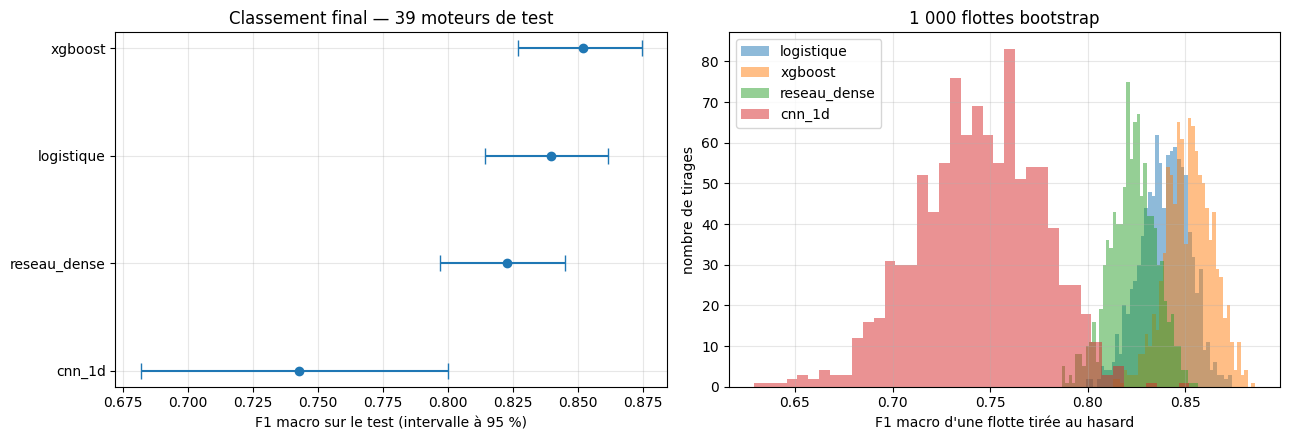

In [9]:
ordre = intervalles.sort_values("f1_macro_test").index
figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))

milieu = intervalles.loc[ordre, "f1_macro_test"]
erreurs = [milieu - intervalles.loc[ordre, "ic95_bas"], intervalles.loc[ordre, "ic95_haut"] - milieu]
axes[0].errorbar(milieu, range(len(ordre)), xerr=erreurs, fmt="o", capsize=6)
axes[0].set_yticks(range(len(ordre)), ordre)
axes[0].set_xlabel("F1 macro sur le test (intervalle à 95 %)")
axes[0].set_title("Classement final — 39 moteurs de test")
axes[0].grid(alpha=0.3)

for nom in MODELES:
    axes[1].hist(tirages[nom], bins=40, alpha=0.5, label=nom)
axes[1].set_xlabel("F1 macro d'une flotte tirée au hasard")
axes[1].set_ylabel("nombre de tirages")
axes[1].set_title("1 000 flottes bootstrap")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/47_classement_test.png", dpi=150)
plt.show()

In [10]:
from aeroguard.outils import chrono

couts = pd.DataFrame({
    "taille_modele": {
        "logistique": f"{alerte_logistique[-1].coef_.size + 1} poids",
        "xgboost": f"{alerte_xgboost.get_booster().num_boosted_rounds()} arbres",
        "reseau_dense": f"{nombre_parametres_entrainables(reseau_dense)} poids",
        "cnn_1d": f"{nombre_parametres_entrainables(cnn)} poids",
    },
    "fichier_ko": {
        "logistique": len(pickle.dumps(alerte_logistique)) / 1024,
        "xgboost": os.path.getsize(f"{DOSSIER}/models/xgb_binaire_v3.json") / 1024,
        "reseau_dense": os.path.getsize(f"{DOSSIER}/models/reseau_dense_regularise_v4.keras") / 1024,
        "cnn_1d": os.path.getsize(f"{DOSSIER}/models/cnn_1d_v4.keras") / 1024,
    },
    "prediction_test_s": {
        "logistique": chrono(lambda: alerte_logistique.predict_proba(X_test)),
        "xgboost": chrono(lambda: alerte_xgboost.predict_proba(X_test)),
        "reseau_dense": chrono(lambda: reseau_dense.predict(Xa_test, batch_size=1024, verbose=0)),
        "cnn_1d": chrono(lambda: cnn.predict(X_test_fenetres, batch_size=1024, verbose=0)),
    },
    "entree": {
        "logistique": "126 features", "xgboost": "126 features",
        "reseau_dense": "126 features", "cnn_1d": "4 × 256 s × 18 canaux",
    },
})
couts["f1_macro_test"] = bilan_test["f1_macro"].astype(float)
couts.round(3)

,taille_modele,fichier_ko,prediction_test_s,entree,f1_macro_test
logistique,127 poids,8.199,0.007,126 features,0.840
xgboost,461 arbres,852.535,0.023,126 features,0.852
reseau_dense,10241 poids,153.740,0.076,126 features,0.823
cnn_1d,47265 poids,592.901,3.101,4 × 256 s × 18 canaux,0.743


In [11]:
from sklearn.metrics import f1_score

lignes = []
for famille, groupe in table_test.groupby("famille"):
    masque = (table_test["famille"] == famille).to_numpy()
    ligne = {"famille": famille, "moteurs": groupe["moteur"].nunique()}
    for nom in MODELES:
        ligne[nom] = f1_score(groupe["y"], alertes_test[nom][masque], average="macro", zero_division=0)
    lignes.append(ligne)
par_famille = pd.DataFrame(lignes).set_index("famille")
par_famille["ecart_cnn_xgboost"] = par_famille["cnn_1d"] - par_famille["xgboost"]
par_famille.sort_values("ecart_cnn_xgboost").round(3)

,moteurs,logistique,xgboost,reseau_dense,cnn_1d,ecart_cnn_xgboost
famille,,,,,,
fan,4,0.787,0.777,0.767,0.288,-0.488
LPC+HPC,4,0.833,0.836,0.820,0.697,-0.139
HPC,4,0.860,0.864,0.815,0.727,-0.137
HPT,4,0.869,0.917,0.852,0.802,-0.115
LPT,4,0.870,0.850,0.835,0.739,-0.110
mixte,10,0.863,0.851,0.831,0.857,0.007
HPT+LPT,9,0.790,0.857,0.816,0.867,0.011


In [12]:
def scores_numeriques(scores):
    """Garde seulement les nombres valides (MLflow refuse le texte et les NaN)."""
    propres = {}
    for cle, valeur in scores.items():
        try:
            nombre = float(valeur)
        except (TypeError, ValueError):
            continue
        if not math.isnan(nombre):
            propres[cle] = nombre
    return propres


os.makedirs(f"{DOSSIER}/results", exist_ok=True)
resultats_v4 = bilan_test.join(intervalles[["ic95_bas", "ic95_haut"]])
resultats_v4.to_csv(f"{DOSSIER}/results/v4_test_alerte.csv")
comparaison.to_csv(f"{DOSSIER}/results/v4_comparaison_xgboost.csv")
couts.to_csv(f"{DOSSIER}/results/v4_couts.csv")
par_famille.to_csv(f"{DOSSIER}/results/v4_par_famille.csv")

mlflow.set_experiment("aeroguard-alerte")
with mlflow.start_run(run_name="lecon_47_test_final"):
    mlflow.set_tags({"lecon": "4.7", "tache": "alerte", "jeu": "test"})
    for nom in MODELES:
        with mlflow.start_run(run_name=f"{nom}_test", nested=True):
            mlflow.set_tags({"lecon": "4.7", "tache": "alerte", "jeu": "test"})
            mlflow.log_params({"modele": nom, "seuil": round(CONFIG_FIGEE[nom]["seuil"], 2),
                               "fenetre_confirmation": K, "source_seuil": CONFIG_FIGEE[nom]["source"]})
            mlflow.log_metrics(scores_numeriques(bilan[nom]))
            mlflow.log_metrics({"ic95_bas": intervalles.loc[nom, "ic95_bas"],
                                "ic95_haut": intervalles.loc[nom, "ic95_haut"]})
    mlflow.log_artifact(f"{DOSSIER}/results/figures/47_classement_test.png")
    mlflow.log_artifact(f"{DOSSIER}/results/v4_test_alerte.csv")
    mlflow.log_artifact(f"{DOSSIER}/results/v4_comparaison_xgboost.csv")
print("✅ Résultats v4 enregistrés (Drive + MLflow)")

✅ Résultats v4 enregistrés (Drive + MLflow)


In [13]:
dossiers_artifacts = set()
for experience in mlflow.search_experiments():
    emplacement = experience.artifact_location.replace("file://", "")
    if emplacement.startswith("/content") and not emplacement.startswith("/content/drive"):
        dossiers_artifacts.add(os.path.dirname(emplacement))

shutil.copytree(DOSSIER_MLFLOW_LOCAL, DOSSIER_MLFLOW_DRIVE, dirs_exist_ok=True)
for dossier in dossiers_artifacts:
    if os.path.exists(dossier):
        shutil.copytree(dossier, f"{DOSSIER}/{os.path.basename(dossier)}", dirs_exist_ok=True)
print("✅ MLflow sauvegardé sur Drive")

✅ MLflow sauvegardé sur Drive
